<a href="https://colab.research.google.com/github/carlosanjoss/Understanding-Structural-Failure-Modes-in-OCTMNIST-/blob/main/Parte_1_2026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Med-LDLMO-CWS

In [ ]:
!pip install -q medmnist
!pip install -q pyswarm
!pip install -q albumentations
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.2 MB/s eta 0:00:00


In [ ]:
import os
import gc
import random
import warnings
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import models

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.cluster import KMeans

from pyswarm import pso

import medmnist
from medmnist import INFO

from torch.cuda.amp import autocast, GradScaler

from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

warnings.filterwarnings("ignore")

In [ ]:
def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(42)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
print(torch.cuda.get_device_name(0))

cuda
Tesla T4


In [ ]:
train_transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.2
    ),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=10,
        border_mode=0,
        p=0.1
    ),

    A.Normalize(
        mean=[0.5],
        std=[0.5]
    ),

    ToTensorV2()

])

In [ ]:
valid_transform = A.Compose([

    A.Normalize(
        mean=[0.5],
        std=[0.5]
    ),

    ToTensorV2()

])

In [ ]:
data_flag = 'octmnist'

info = INFO[data_flag]

DataClass = getattr(medmnist, info['python_class'])

In [ ]:
train_dataset_raw = DataClass(
    split='train',
    download=True
)

val_dataset_raw = DataClass(
    split='val',
    download=True
)

test_dataset_raw = DataClass(
    split='test',
    download=True
)

100%|██████████| 54.9M/54.9M [00:03<00:00, 17.5MB/s]


In [ ]:
class OCTDataset(Dataset):

    def __init__(self, dataset, transform=None):

        self.dataset = dataset
        self.transform = transform

    def __len__(self):

        return len(self.dataset)

    def __getitem__(self, idx):

        image, label = self.dataset[idx]

        image = np.array(image)

        if len(image.shape) == 2:

            image = np.expand_dims(image, axis=-1)

        label = int(label)

        if self.transform:

            augmented = self.transform(image=image)

            image = augmented["image"]

        return image.float(), torch.tensor(label).long()

In [ ]:
train_dataset = OCTDataset(
    train_dataset_raw,
    transform=train_transform
)

val_dataset = OCTDataset(
    val_dataset_raw,
    transform=valid_transform
)

test_dataset = OCTDataset(
    test_dataset_raw,
    transform=valid_transform
)

In [ ]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([1, 28, 28])
tensor(0)


In [ ]:
targets = []

for _, label in train_dataset:
    targets.append(label.item())

targets = np.array(targets)

In [ ]:
class_counts = np.bincount(targets)

class_weights = 1. / class_counts

sample_weights = class_weights[targets]

In [ ]:
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(

    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,

    num_workers=2,
    pin_memory=True,

    drop_last=True
)

In [ ]:
val_loader = DataLoader(

    val_dataset,
    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,
    pin_memory=True
)

In [ ]:
test_loader = DataLoader(

    test_dataset,
    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,
    pin_memory=True
)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32])


In [ ]:
class ChannelAttention(nn.Module):

    def __init__(self, in_channels, reduction=8):

        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(

            nn.Conv2d(
                in_channels,
                in_channels // reduction,
                kernel_size=1,
                bias=False
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels // reduction,
                in_channels,
                kernel_size=1,
                bias=False
            )

        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = self.mlp(self.avg_pool(x))

        max_out = self.mlp(self.max_pool(x))

        out = avg_out + max_out

        return self.sigmoid(out)

In [ ]:
class SpatialAttention(nn.Module):

    def __init__(self, kernel_size=7):

        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=kernel_size,
            padding=padding,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = torch.mean(x, dim=1, keepdim=True)

        max_out, _ = torch.max(x, dim=1, keepdim=True)

        out = torch.cat([avg_out, max_out], dim=1)

        out = self.conv(out)

        return self.sigmoid(out)

In [ ]:
class CBAM(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.channel_attention = ChannelAttention(channels)

        self.spatial_attention = SpatialAttention()

    def forward(self, x):

        ca = self.channel_attention(x)

        x = x * ca

        sa = self.spatial_attention(x)

        x = x * sa

        return x

In [ ]:
class DepthwiseSeparableConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):

        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            groups=in_channels,
            bias=False
        )

        self.pointwise = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            bias=False
        )

        self.bn = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        x = self.depthwise(x)

        x = self.pointwise(x)

        x = self.bn(x)

        x = self.relu(x)

        return x

In [ ]:
class ResidualDSCBAMBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):

        super().__init__()

        self.conv1 = DepthwiseSeparableConv(
            in_channels,
            out_channels,
            stride
        )

        self.conv2 = DepthwiseSeparableConv(
            out_channels,
            out_channels,
            stride=1
        )

        self.cbam = CBAM(out_channels)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(out_channels)

            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)

        out = self.conv2(out)

        out = self.cbam(out)

        out += identity

        out = self.relu(out)

        return out

In [ ]:
class LightweightMedNet(nn.Module):

    def __init__(
        self,
        channels=[16,32,64,96,128],
        num_classes=4,
        dropout=0.3
    ):

        super().__init__()

        self.stem = nn.Sequential(

            nn.Conv2d(
                1,
                channels[0],
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(channels[0]),

            nn.ReLU(inplace=True)

        )

        self.layer1 = ResidualDSCBAMBlock(
            channels[0],
            channels[0],
            stride=1
        )

        self.layer2 = ResidualDSCBAMBlock(
            channels[0],
            channels[1],
            stride=2
        )

        self.layer3 = ResidualDSCBAMBlock(
            channels[1],
            channels[2],
            stride=1
        )

        self.layer4 = ResidualDSCBAMBlock(
            channels[2],
            channels[3],
            stride=2
        )

        self.layer5 = ResidualDSCBAMBlock(
            channels[3],
            channels[4],
            stride=1
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            channels[4],
            num_classes
        )

    def forward(self, x):

        x = self.stem(x)

        x = self.layer1(x)

        x = self.layer2(x)

        x = self.layer3(x)

        x = self.layer4(x)

        x = self.layer5(x)

        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.dropout(x)

        x = self.fc(x)

        return x

In [ ]:
model = LightweightMedNet().to(device)

dummy = torch.randn(2,1,28,28).to(device)

output = model(dummy)

print(output.shape)

torch.Size([2, 4])


In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(total_params)
print(trainable_params)

89166
89166


In [ ]:
class FocalLoss(nn.Module):

    def __init__(
        self,
        alpha=None,
        gamma=2.0,
        reduction='mean'
    ):

        super().__init__()

        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):

        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction='none'
        )

        pt = torch.exp(-ce_loss)

        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.alpha is not None:

            alpha_t = self.alpha[targets]

            focal_loss = alpha_t * focal_loss

        if self.reduction == 'mean':

            return focal_loss.mean()

        elif self.reduction == 'sum':

            return focal_loss.sum()

        else:

            return focal_loss

In [ ]:
class_counts = np.bincount(targets)

class_weights = 1.0 / class_counts

class_weights = class_weights / class_weights.sum()

alpha = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

In [ ]:
criterion = FocalLoss(
    alpha=alpha,
    gamma=2.0
)

In [ ]:
def extract_features(model, loader):

    model.eval()

    features = []
    labels = []

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(device)

            x = model.stem(images)

            x = model.layer1(x)

            x = model.layer2(x)

            x = model.layer3(x)

            x = model.pool(x)

            x = torch.flatten(x, 1)

            features.append(x.cpu())

            labels.append(targets)

    features = torch.cat(features).numpy()

    labels = torch.cat(labels).numpy()

    return features, labels

In [ ]:
model = LightweightMedNet().to(device)

In [ ]:
features, labels = extract_features(
    model,
    train_loader
)

In [ ]:
normal_idx = np.where(labels == 3)[0]

In [ ]:
normal_features = features[normal_idx]

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(normal_features)

In [ ]:
images, labels_batch = next(iter(train_loader))

print(images.shape)
print(labels_batch.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32])


In [ ]:
def compute_class_errors(
    y_true,
    y_pred,
    num_classes=4
):

    errors = {}

    for c in range(num_classes):

        idx = y_true == c

        correct = (y_pred[idx] == y_true[idx]).mean()

        errors[c] = 1.0 - correct

    return errors

In [ ]:
def build_dynamic_weights(
    targets,
    class_errors
):

    weights = []

    for t in targets:

        weights.append(class_errors[int(t)])

    return np.array(weights)

In [ ]:
y_true = np.array([0,0,1,1,2,2,3,3])

y_pred = np.array([0,1,1,1,2,0,3,2])

class_errors = compute_class_errors(
    y_true,
    y_pred,
    num_classes=4
)

print(class_errors)

{0: np.float64(0.5), 1: np.float64(0.0), 2: np.float64(0.5), 3: np.float64(0.5)}


In [ ]:
def build_dynamic_weights(
    targets,
    class_errors,
    beta=1.5,
    epsilon=1e-6
):

    weights = []

    for t in targets:

        w = (class_errors[int(t)] + epsilon) ** beta

        weights.append(w)

    weights = np.array(weights)

    weights = weights / weights.sum()

    return weights

In [ ]:
def fix_channels(channels):

    channels = [int(c) for c in channels]

    channels = [max(8, c) for c in channels]

    channels = sorted(channels)

    return channels

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

def compute_macro_auc(y_true, y_probs, num_classes=4):

    y_true_bin = label_binarize(
        y_true,
        classes=list(range(num_classes))
    )

    auc = roc_auc_score(
        y_true_bin,
        y_probs,
        average='macro',
        multi_class='ovr'
    )

    return auc

In [ ]:
def evaluate_architecture(channels):

    torch.cuda.empty_cache()

    gc.collect()

    channels = fix_channels(channels)

    print(f"Testing channels: {channels}")

    model = LightweightMedNet(
        channels=channels
    ).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )

    scheduler = CosineAnnealingWarmRestarts(
        optimizer,
        T_0=2
    )

    scaler = GradScaler()

    for epoch in range(3):

        model.train()

        running_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            with autocast():

                outputs = model(images)

                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()

            scaler.step(optimizer)

            scaler.update()

            running_loss += loss.item()

        scheduler.step()

        print(f"Epoch {epoch+1} Loss: {running_loss:.4f}")

    model.eval()

    y_true = []

    y_probs = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            with autocast():

                outputs = model(images)

                probs = torch.softmax(outputs, dim=1)

            y_probs.extend(
                probs.cpu().numpy()
            )

            y_true.extend(
                labels.numpy()
            )

    auc = compute_macro_auc(
        np.array(y_true),
        np.array(y_probs)
    )

    print(f"Macro AUC: {auc:.4f}")

    del model

    torch.cuda.empty_cache()

    gc.collect()

    return -auc

In [ ]:
lb = [8, 16, 32, 48, 64]

ub = [32, 64, 96, 128, 160]


best_channels, best_score = pso(

    evaluate_architecture,

    lb=lb,

    ub=ub,

    swarmsize=4,

    maxiter=5,

    debug=True

)


best_channels = fix_channels(best_channels)

best_auc = -best_score


print("\n========== RESULTADO FINAL DO PSO ==========")

print(f"Melhores canais: {best_channels}")

print(f"Melhor Macro-AUC: {best_auc:.4f}")

No constraints given.
Testing channels: [29, 37, 55, 94, 114]
Epoch 1 Loss: 223.7594
Epoch 2 Loss: 152.3407
Epoch 3 Loss: 146.1039
Macro AUC: 0.9442
Testing channels: [14, 32, 38, 67, 124]
Epoch 1 Loss: 240.3091
Epoch 2 Loss: 166.3207
Epoch 3 Loss: 157.4097
Macro AUC: 0.9452
Testing channels: [31, 43, 59, 85, 134]
Epoch 1 Loss: 223.3909
Epoch 2 Loss: 143.0913
Epoch 3 Loss: 142.0684
Macro AUC: 0.9486
Testing channels: [8, 52, 86, 93, 155]
Epoch 1 Loss: 217.0028
Epoch 2 Loss: 145.3149
Epoch 3 Loss: 141.0033
Macro AUC: 0.9482
Testing channels: [26, 32, 57, 64, 88]
Epoch 1 Loss: 229.8023
Epoch 2 Loss: 155.6222
Epoch 3 Loss: 151.6646
Macro AUC: 0.9477
Testing channels: [20, 40, 40, 110, 128]
Epoch 1 Loss: 220.4748
Epoch 2 Loss: 148.7641
Epoch 3 Loss: 147.1260
Macro AUC: 0.9475
Testing channels: [31, 55, 60, 108, 160]
Epoch 1 Loss: 217.1688
Epoch 2 Loss: 139.0099
Epoch 3 Loss: 136.2560
Macro AUC: 0.9569
Testing channels: [13, 48, 51, 57, 129]
Epoch 1 Loss: 234.3686
Epoch 2 Loss: 153.9913
Epo

In [ ]:
model = LightweightMedNet(

    channels=best_channels,

    num_classes=4,

    dropout=0.3

).to(device)

In [ ]:
optimizer = optim.AdamW(

    model.parameters(),

    lr=1e-3,

    weight_decay=1e-4

)


scheduler = CosineAnnealingWarmRestarts(

    optimizer,

    T_0=5

)


scaler = GradScaler()

In [ ]:
best_val_loss = np.inf

patience = 7

counter = 0

In [ ]:
EPOCHS = 50

history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": []
}


for epoch in range(EPOCHS):

    torch.cuda.empty_cache()

    gc.collect()

    model.train()

    train_loss = 0.0

    for images, labels in tqdm(train_loader):

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    scheduler.step()

    model.eval()

    val_loss = 0.0

    y_true = []

    y_probs = []

    y_preds = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            with autocast():

                outputs = model(images)

                loss = criterion(outputs, labels)

                probs = torch.softmax(outputs, dim=1)

            val_loss += loss.item()

            preds = torch.argmax(probs, dim=1)

            y_true.extend(labels.cpu().numpy())

            y_probs.extend(probs.cpu().numpy())

            y_preds.extend(preds.cpu().numpy())

    val_loss /= len(val_loader)

    val_auc = compute_macro_auc(

        np.array(y_true),

        np.array(y_probs)

    )

    val_acc = accuracy_score(y_true, y_preds)

    history["train_loss"].append(train_loss)

    history["val_loss"].append(val_loss)

    history["val_auc"].append(val_auc)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Val Loss: {val_loss:.4f}")

    print(f"Val Accuracy: {val_acc:.4f}")

    print(f"Val Macro-AUC: {val_auc:.4f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        counter = 0

        torch.save(

            model.state_dict(),

            "best_medldlmo_model.pth"

        )

        print("Melhor modelo salvo.")

    else:

        counter += 1

        print(f"EarlyStopping Counter: {counter}")

    if counter >= patience:

        print("Early stopping ativado.")

        break

100%|██████████| 3046/3046 [01:13<00:00, 41.62it/s]



Epoch 1/50
Train Loss: 0.0708
Val Loss: 0.0641
Val Accuracy: 0.5008
Val Macro-AUC: 0.9300
Melhor modelo salvo.


100%|██████████| 3046/3046 [01:12<00:00, 42.18it/s]



Epoch 2/50
Train Loss: 0.0487
Val Loss: 0.0482
Val Accuracy: 0.4646
Val Macro-AUC: 0.9467
Melhor modelo salvo.


100%|██████████| 3046/3046 [01:14<00:00, 41.12it/s]


...


Epoch 15/50
Train Loss: 0.0259
Val Loss: 0.0270
Val Accuracy: 0.6846
Val Macro-AUC: 0.9688
EarlyStopping Counter: 5


100%|██████████| 3046/3046 [01:11<00:00, 42.85it/s]



Epoch 16/50
Train Loss: 0.0323
Val Loss: 0.0280
Val Accuracy: 0.6895
Val Macro-AUC: 0.9664
EarlyStopping Counter: 6


100%|██████████| 3046/3046 [01:11<00:00, 42.67it/s]



Epoch 17/50
Train Loss: 0.0313
Val Loss: 0.0274
Val Accuracy: 0.7034
Val Macro-AUC: 0.9668
EarlyStopping Counter: 7
Early stopping ativado.


In [ ]:
model.load_state_dict(

    torch.load("best_medldlmo_model.pth")

)

model.eval()

LightweightMedNet(
  (stem): Sequential(
    (0): Conv2d(1, 31, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(31, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): ResidualDSCBAMBlock(
    (conv1): DepthwiseSeparableConv(
      (depthwise): Conv2d(31, 31, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=31, bias=False)
      (pointwise): Conv2d(31, 31, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(31, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (conv2): DepthwiseSeparableConv(
      (depthwise): Conv2d(31, 31, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=31, bias=False)
      (pointwise): Conv2d(31, 31, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(31, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (

In [ ]:
y_true = []

y_probs = []

y_preds = []


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        with autocast():

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.numpy())

        y_probs.extend(probs.cpu().numpy())

        y_preds.extend(preds.cpu().numpy())

In [ ]:
test_acc = accuracy_score(

    y_true,

    y_preds

)


test_auc = compute_macro_auc(

    np.array(y_true),

    np.array(y_probs)

)


print("\n========== RESULTADOS FINAIS ==========")

print(f"Test Accuracy: {test_acc:.4f}")

print(f"Test Macro-AUC: {test_auc:.4f}")


========== RESULTADOS FINAIS ==========
Test Accuracy: 0.7940
Test Macro-AUC: 0.9650


In [ ]:
print(

    classification_report(

        y_true,

        y_preds,

        target_names=[

            "CNV",

            "DME",

            "Drusen",

            "Normal"

        ]

    )

)

              precision    recall  f1-score   support

         CNV       0.84      0.88      0.86       250
         DME       0.74      0.97      0.84       250
      Drusen       0.72      0.75      0.74       250
      Normal       0.93      0.57      0.71       250

    accuracy                           0.79      1000
   macro avg       0.81      0.79      0.79      1000
weighted avg       0.81      0.79      0.79      1000



In [ ]:
cm = confusion_matrix(

    y_true,

    y_preds

)

print(cm)

[[221  25   4   0]
 [  6 242   2   0]
 [ 33  19 188  10]
 [  2  39  66 143]]


In [ ]:
torch.save({

    "model_state_dict": model.state_dict(),

    "channels": best_channels,

    "auc": test_auc,

    "accuracy": test_acc

},

"medldlmo_final_model.pth")

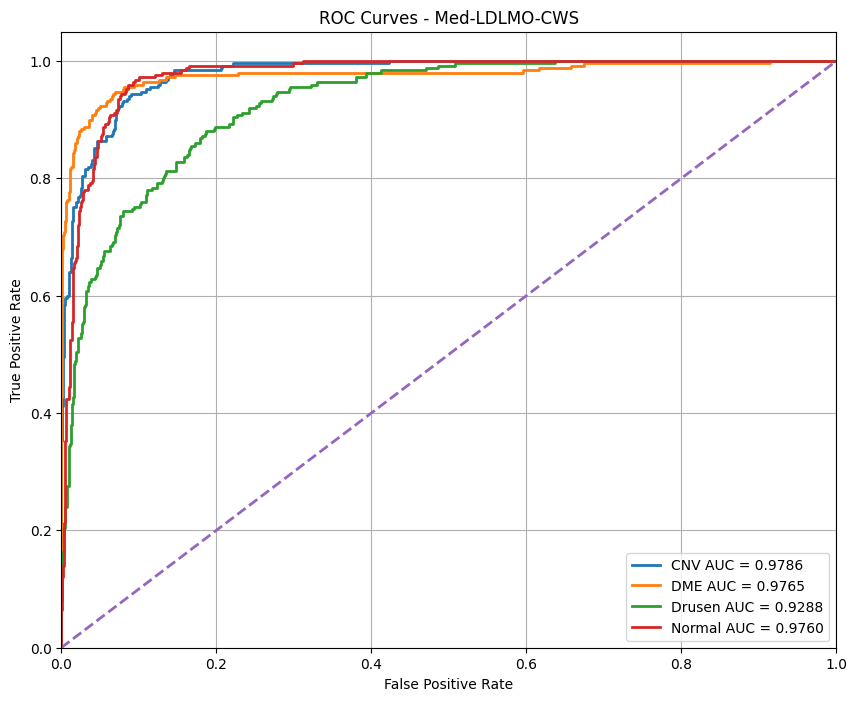

In [ ]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize

from sklearn.metrics import roc_curve, auc


y_true_bin = label_binarize(

    y_true,

    classes=[0,1,2,3]

)


class_names = [

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


fpr = dict()

tpr = dict()

roc_auc = dict()


for i in range(4):

    fpr[i], tpr[i], _ = roc_curve(

        y_true_bin[:, i],

        np.array(y_probs)[:, i]

    )

    roc_auc[i] = auc(

        fpr[i],

        tpr[i]

    )


plt.figure(figsize=(10,8))


for i in range(4):

    plt.plot(

        fpr[i],

        tpr[i],

        lw=2,

        label=f"{class_names[i]} AUC = {roc_auc[i]:.4f}"

    )


plt.plot(

    [0,1],

    [0,1],

    linestyle='--',

    lw=2

)


plt.xlim([0.0,1.0])

plt.ylim([0.0,1.05])

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves - Med-LDLMO-CWS")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

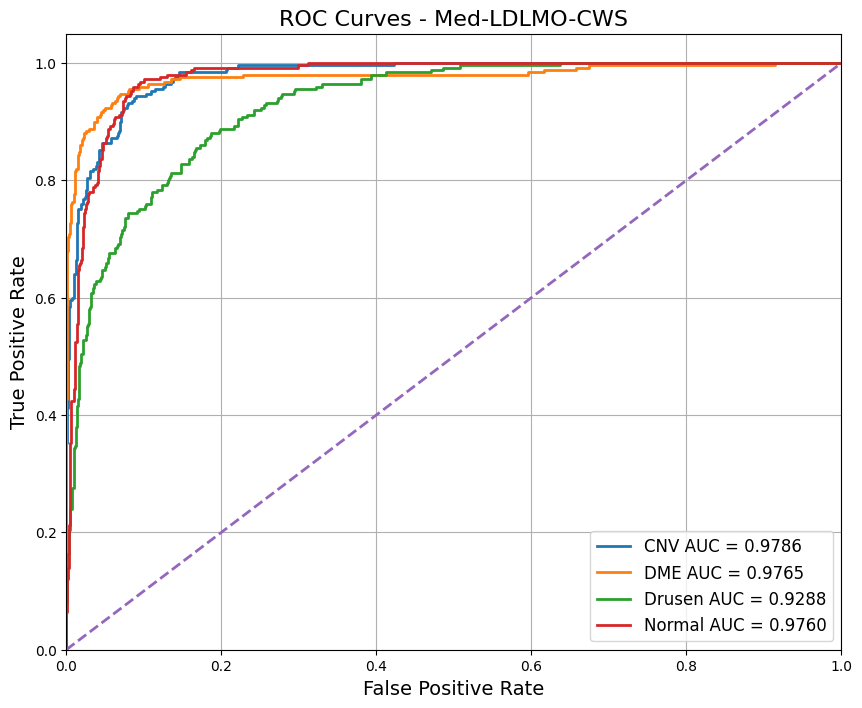

In [ ]:
plt.figure(figsize=(10,8))


for i in range(4):

    plt.plot(

        fpr[i],

        tpr[i],

        lw=2,

        label=f"{class_names[i]} AUC = {roc_auc[i]:.4f}"

    )


plt.plot(

    [0,1],

    [0,1],

    linestyle='--',

    lw=2

)


plt.xlim([0.0,1.0])

plt.ylim([0.0,1.05])

plt.xlabel("False Positive Rate", fontsize=14)

plt.ylabel("True Positive Rate", fontsize=14)

plt.title("ROC Curves - Med-LDLMO-CWS", fontsize=16)

plt.legend(loc="lower right", fontsize=12)

plt.grid(True)


plt.savefig(

    "roc_curves_publication.png",

    dpi=600,

    bbox_inches='tight'

)

plt.show()

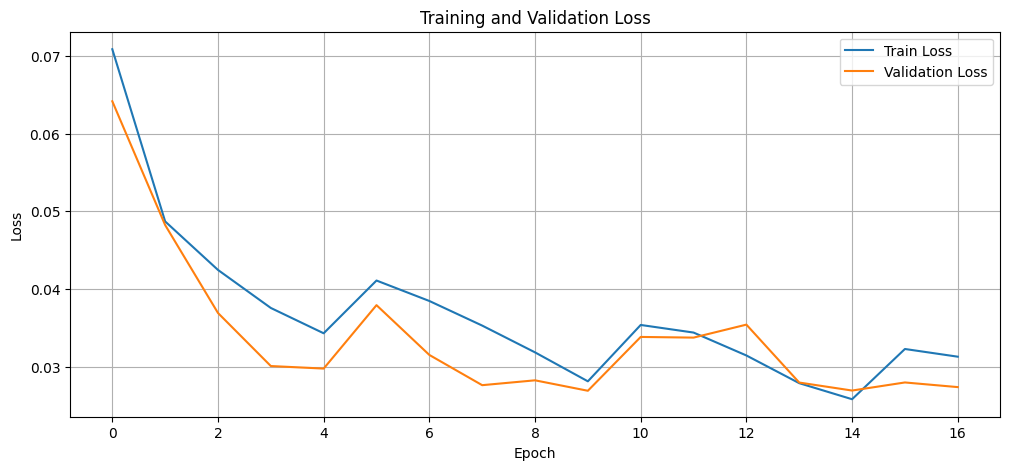

In [ ]:
plt.figure(figsize=(12,5))


plt.plot(

    history["train_loss"],

    label="Train Loss"

)


plt.plot(

    history["val_loss"],

    label="Validation Loss"

)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

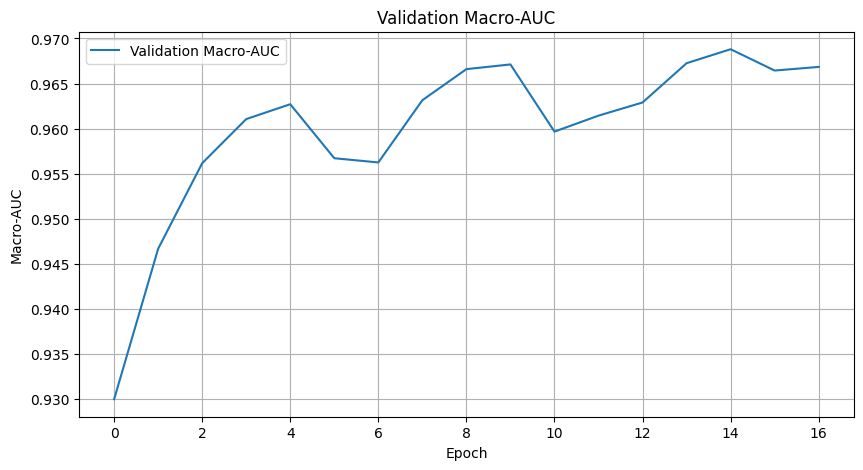

In [ ]:
plt.figure(figsize=(10,5))


plt.plot(

    history["val_auc"],

    label="Validation Macro-AUC"

)


plt.xlabel("Epoch")

plt.ylabel("Macro-AUC")

plt.title("Validation Macro-AUC")

plt.legend()

plt.grid(True)

plt.show()

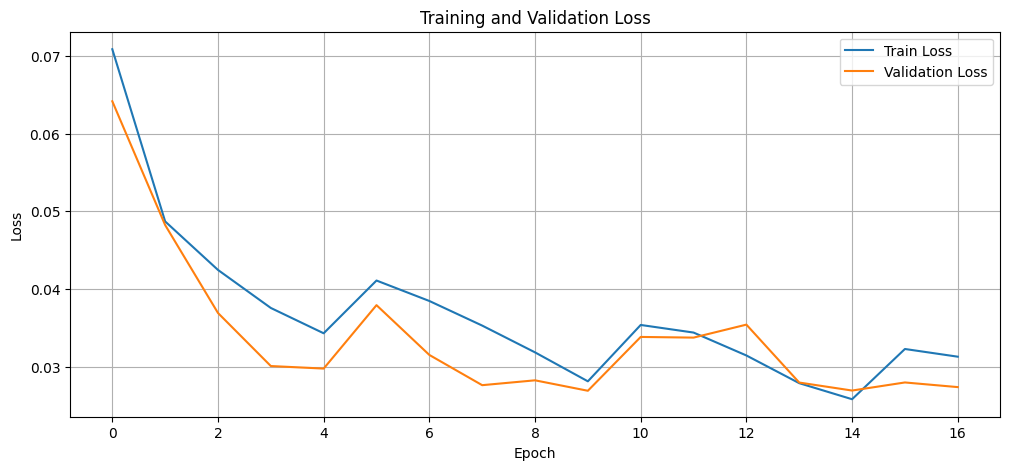

In [ ]:
plt.figure(figsize=(12,5))


plt.plot(

    history["train_loss"],

    label="Train Loss"

)


plt.plot(

    history["val_loss"],

    label="Validation Loss"

)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.grid(True)


plt.savefig(

    "loss_curves.png",

    dpi=600,

    bbox_inches='tight'

)

plt.show()

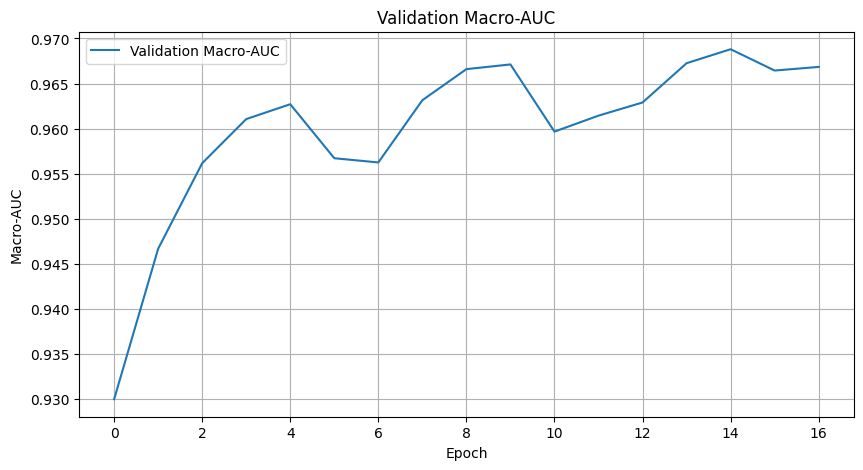

In [ ]:
plt.figure(figsize=(10,5))


plt.plot(

    history["val_auc"],

    label="Validation Macro-AUC"

)


plt.xlabel("Epoch")

plt.ylabel("Macro-AUC")

plt.title("Validation Macro-AUC")

plt.legend()

plt.grid(True)


plt.savefig(

    "auc_curve.png",

    dpi=600,

    bbox_inches='tight'

)

plt.show()

In [ ]:
import pandas as pd

from sklearn.metrics import (

    precision_score,

    recall_score,

    f1_score,

    classification_report

)


report = classification_report(

    y_true,

    y_preds,

    target_names=[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ],

    output_dict=True

)


results_table = pd.DataFrame(report).transpose()


overall_metrics = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Macro-AUC",

        "Macro Precision",

        "Macro Recall",

        "Macro F1-Score"

    ],

    "Value": [

        accuracy_score(y_true, y_preds),

        test_auc,

        precision_score(

            y_true,

            y_preds,

            average='macro'

        ),

        recall_score(

            y_true,

            y_preds,

            average='macro'

        ),

        f1_score(

            y_true,

            y_preds,

            average='macro'

        )

    ]

})


print("\n========== OVERALL METRICS ==========\n")

print(overall_metrics)


print("\n========== CLASSIFICATION REPORT ==========\n")

print(results_table)


========== OVERALL METRICS ==========

            Metric     Value
0         Accuracy  0.794000
1        Macro-AUC  0.964979
2  Macro Precision  0.811461
3     Macro Recall  0.794000
4   Macro F1-Score  0.787988

========== CLASSIFICATION REPORT ==========

              precision  recall  f1-score   support
CNV            0.843511   0.884  0.863281   250.000
DME            0.744615   0.968  0.841739   250.000
Drusen         0.723077   0.752  0.737255   250.000
Normal         0.934641   0.572  0.709677   250.000
accuracy       0.794000   0.794  0.794000     0.794
macro avg      0.811461   0.794  0.787988  1000.000
weighted avg   0.811461   0.794  0.787988  1000.000


In [ ]:
paper_table = pd.DataFrame({

    "Class": [

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ],

    "Precision": [

        report["CNV"]["precision"],

        report["DME"]["precision"],

        report["Drusen"]["precision"],

        report["Normal"]["precision"]

    ],

    "Recall": [

        report["CNV"]["recall"],

        report["DME"]["recall"],

        report["Drusen"]["recall"],

        report["Normal"]["recall"]

    ],

    "F1-Score": [

        report["CNV"]["f1-score"],

        report["DME"]["f1-score"],

        report["Drusen"]["f1-score"],

        report["Normal"]["f1-score"]

    ],

    "AUC": [

        roc_auc[0],

        roc_auc[1],

        roc_auc[2],

        roc_auc[3]

    ]

})


paper_table = paper_table.round(4)


print(paper_table)

    Class  Precision  Recall  F1-Score     AUC
0     CNV     0.8435   0.884    0.8633  0.9786
1     DME     0.7446   0.968    0.8417  0.9765
2  Drusen     0.7231   0.752    0.7373  0.9288
3  Normal     0.9346   0.572    0.7097  0.9760


GRAD-CAM

In [ ]:
gradients = None

activations = None


def backward_hook(module, grad_input, grad_output):

    global gradients

    gradients = grad_output[0]


def forward_hook(module, input, output):

    global activations

    activations = output

In [ ]:
target_layer = model.layer5


target_layer.register_forward_hook(

    forward_hook

)


target_layer.register_full_backward_hook(

    backward_hook

)

In [ ]:
def generate_gradcam(model, image_tensor, class_idx=None):

    global gradients

    global activations

    model.eval()

    image_tensor = image_tensor.unsqueeze(0).to(device)

    output = model(image_tensor)

    if class_idx is None:

        class_idx = output.argmax(dim=1).item()

    model.zero_grad()

    loss = output[:, class_idx]

    loss.backward()

    grads = gradients.detach().cpu()[0]

    acts = activations.detach().cpu()[0]

    pooled_grads = torch.mean(

        grads,

        dim=[1,2]

    )

    for i in range(len(pooled_grads)):

        acts[i] *= pooled_grads[i]

    heatmap = torch.mean(

        acts,

        dim=0

    ).numpy()

    heatmap = np.maximum(

        heatmap,

        0

    )

    heatmap /= np.max(heatmap) + 1e-8

    return heatmap, class_idx

In [ ]:
sample_image, sample_label = test_dataset[0]

print(sample_image.shape)

print(sample_label)

torch.Size([1, 28, 28])
tensor(3)


In [ ]:
heatmap, predicted_class = generate_gradcam(

    model,

    sample_image

)

print("Classe prevista:", predicted_class)

Classe prevista: 2


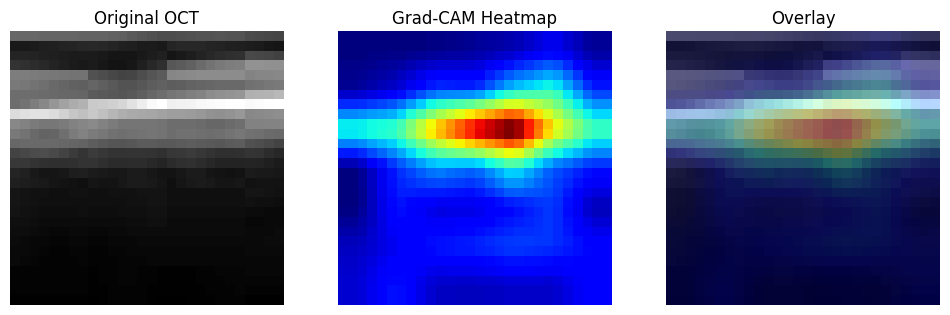

In [ ]:
import cv2

import matplotlib.pyplot as plt


image_np = sample_image.squeeze().numpy()


heatmap_resized = cv2.resize(

    heatmap,

    (28,28)

)


heatmap_uint8 = np.uint8(

    255 * heatmap_resized

)


heatmap_color = cv2.applyColorMap(

    heatmap_uint8,

    cv2.COLORMAP_JET

)


heatmap_color = cv2.cvtColor(

    heatmap_color,

    cv2.COLOR_BGR2RGB

)


image_rgb = np.stack(

    [image_np]*3,

    axis=-1

)


image_rgb = (

    (image_rgb - image_rgb.min())

    /

    (image_rgb.max() - image_rgb.min() + 1e-8)

)


overlay = (

    0.4 * heatmap_color / 255.0

    +

    image_rgb

)


overlay = overlay / overlay.max()


plt.figure(figsize=(12,4))


plt.subplot(1,3,1)

plt.imshow(

    image_np,

    cmap='gray'

)

plt.title("Original OCT")

plt.axis('off')


plt.subplot(1,3,2)

plt.imshow(

    heatmap_resized,

    cmap='jet'

)

plt.title("Grad-CAM Heatmap")

plt.axis('off')


plt.subplot(1,3,3)

plt.imshow(overlay)

plt.title("Overlay")

plt.axis('off')


plt.show()

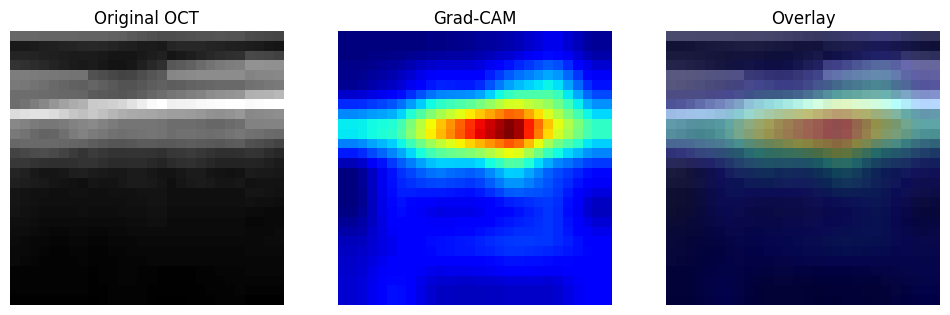

In [ ]:
plt.figure(figsize=(12,4))


plt.subplot(1,3,1)

plt.imshow(

    image_np,

    cmap='gray'

)

plt.title("Original OCT")

plt.axis('off')


plt.subplot(1,3,2)

plt.imshow(

    heatmap_resized,

    cmap='jet'

)

plt.title("Grad-CAM")

plt.axis('off')


plt.subplot(1,3,3)

plt.imshow(overlay)

plt.title("Overlay")

plt.axis('off')


plt.savefig(

    "gradcam_publication.png",

    dpi=600,

    bbox_inches='tight'

)

plt.show()

Ablation Study

In [ ]:
class ResidualDSBlock_NoCBAM(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):

        super().__init__()

        self.conv1 = DepthwiseSeparableConv(
            in_channels,
            out_channels,
            stride
        )

        self.conv2 = DepthwiseSeparableConv(
            out_channels,
            out_channels
        )

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(out_channels)

            )

        self.relu = nn.ReLU(inplace=False)

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)

        out = self.conv2(out)

        out = out + identity

        out = self.relu(out)

        return out

In [ ]:
class LightweightMedNet_NoCBAM(nn.Module):

    def __init__(
        self,
        channels=[16,32,64,96,128],
        num_classes=4
    ):

        super().__init__()

        self.stem = nn.Sequential(

            nn.Conv2d(
                1,
                channels[0],
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(channels[0]),

            nn.ReLU(inplace=True)

        )

        self.layer1 = ResidualDSBlock_NoCBAM(
            channels[0],
            channels[0]
        )

        self.layer2 = ResidualDSBlock_NoCBAM(
            channels[0],
            channels[1],
            stride=2
        )

        self.layer3 = ResidualDSBlock_NoCBAM(
            channels[1],
            channels[2]
        )

        self.layer4 = ResidualDSBlock_NoCBAM(
            channels[2],
            channels[3],
            stride=2
        )

        self.layer5 = ResidualDSBlock_NoCBAM(
            channels[3],
            channels[4]
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(
            channels[4],
            num_classes
        )

    def forward(self, x):

        x = self.stem(x)

        x = self.layer1(x)

        x = self.layer2(x)

        x = self.layer3(x)

        x = self.layer4(x)

        x = self.layer5(x)

        x = self.pool(x)

        x = torch.flatten(x,1)

        x = self.fc(x)

        return x

In [ ]:
def quick_evaluate(model_class, use_focal=True):

    model = model_class(

        channels=best_channels

    ).to(device)

    optimizer = optim.AdamW(

        model.parameters(),

        lr=1e-3,

        weight_decay=1e-4

    )

    scaler = GradScaler()

    if use_focal:

        loss_fn = criterion

    else:

        loss_fn = nn.CrossEntropyLoss()

    for epoch in range(5):

        model.train()

        for images, labels in train_loader:

            images = images.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            with autocast():

                outputs = model(images)

                loss = loss_fn(outputs, labels)

            scaler.scale(loss).backward()

            scaler.step(optimizer)

            scaler.update()

    model.eval()

    y_true = []

    y_probs = []

    y_preds = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            with autocast():

                outputs = model(images)

                probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(probs, dim=1)

            y_true.extend(labels.cpu().numpy())

            y_probs.extend(probs.cpu().numpy())

            y_preds.extend(preds.cpu().numpy())

    acc = accuracy_score(

        y_true,

        y_preds

    )

    auc = compute_macro_auc(

        np.array(y_true),

        np.array(y_probs)

    )

    del model

    torch.cuda.empty_cache()

    gc.collect()

    return acc, auc

In [ ]:
ablation_results = []

In [ ]:
acc, auc = quick_evaluate(

    LightweightMedNet_NoCBAM,

    use_focal=False

)

ablation_results.append({

    "Model": "Without CBAM + CE",

    "Accuracy": acc,

    "Macro-AUC": auc

})

In [ ]:
acc, auc = quick_evaluate(

    LightweightMedNet_NoCBAM,

    use_focal=True

)

ablation_results.append({

    "Model": "Without CBAM + Focal",

    "Accuracy": acc,

    "Macro-AUC": auc

})

In [ ]:
acc, auc = quick_evaluate(

    LightweightMedNet,

    use_focal=False

)

ablation_results.append({

    "Model": "With CBAM + CE",

    "Accuracy": acc,

    "Macro-AUC": auc

})

In [ ]:
acc, auc = quick_evaluate(

    LightweightMedNet,

    use_focal=True

)

ablation_results.append({

    "Model": "Full Model",

    "Accuracy": acc,

    "Macro-AUC": auc

})

In [ ]:
ablation_df = pd.DataFrame(

    ablation_results

)

ablation_df = ablation_df.round(4)

print(ablation_df)

                  Model  Accuracy  Macro-AUC
0     Without CBAM + CE    0.8223     0.9650
1  Without CBAM + Focal    0.6004     0.9596
2        With CBAM + CE    0.8270     0.9642
3            Full Model    0.6311     0.9612


In [ ]:
ablation_df.to_csv(

    "ablation_study.csv",

    index=False

)

print("Ablation Study salva.")

Ablation Study salva.


In [ ]:
Med-MobileVit-LT

In [ ]:
!pip install -q medmnist albumentations


import medmnist
import albumentations as A

from medmnist import INFO

from torch.utils.data import (
    Dataset,
    DataLoader
)

from albumentations.pytorch import ToTensorV2



train_transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomBrightnessContrast(

        brightness_limit=0.1,

        contrast_limit=0.1,

        p=0.2

    ),

    A.ShiftScaleRotate(

        shift_limit=0.05,

        scale_limit=0.05,

        rotate_limit=10,

        border_mode=0,

        p=0.1

    ),

    A.Normalize(

        mean=[0.5],

        std=[0.5]

    ),

    ToTensorV2()

])


valid_transform = A.Compose([

    A.Normalize(

        mean=[0.5],

        std=[0.5]

    ),

    ToTensorV2()

])



data_flag = "octmnist"

info = INFO[data_flag]

DataClass = getattr(

    medmnist,

    info["python_class"]

)



train_dataset_raw = DataClass(

    split="train",

    download=True

)


val_dataset_raw = DataClass(

    split="val",

    download=True

)


test_dataset_raw = DataClass(

    split="test",

    download=True

)



class OCTDataset(Dataset):

    def __init__(

        self,

        dataset,

        transform=None

    ):

        self.dataset = dataset

        self.transform = transform


    def __len__(self):

        return len(self.dataset)


    def __getitem__(

        self,

        idx

    ):

        image, label = self.dataset[idx]

        image = np.array(image)

        if len(image.shape) == 2:

            image = np.expand_dims(

                image,

                axis=-1

            )

        label = int(label)

        if self.transform:

            augmented = self.transform(

                image=image

            )

            image = augmented["image"]

        return image.float(), torch.tensor(label).long()



train_dataset = OCTDataset(

    train_dataset_raw,

    transform=train_transform

)


val_dataset = OCTDataset(

    val_dataset_raw,

    transform=valid_transform

)


test_dataset = OCTDataset(

    test_dataset_raw,

    transform=valid_transform

)



BATCH_SIZE = 32


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True,

    drop_last=True

)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)


print("DataLoaders restored successfully.")

DataLoaders restored successfully.


In [ ]:
class FocalLoss(nn.Module):

    def __init__(

        self,

        alpha=None,

        gamma=2.0,

        reduction='mean'

    ):

        super().__init__()

        self.alpha = alpha

        self.gamma = gamma

        self.reduction = reduction


    def forward(

        self,

        logits,

        targets

    ):

        ce_loss = F.cross_entropy(

            logits,

            targets,

            reduction='none'

        )

        pt = torch.exp(-ce_loss)

        focal_loss = (

            (1 - pt) ** self.gamma

        ) * ce_loss


        if self.alpha is not None:

            alpha_t = self.alpha[targets]

            focal_loss = alpha_t * focal_loss


        if self.reduction == 'mean':

            return focal_loss.mean()

        elif self.reduction == 'sum':

            return focal_loss.sum()

        else:

            return focal_loss

In [ ]:
criterion = FocalLoss()

In [ ]:
from sklearn.metrics import roc_auc_score

from sklearn.preprocessing import label_binarize


def compute_macro_auc(

    y_true,

    y_probs,

    num_classes=4

):

    y_true_bin = label_binarize(

        y_true,

        classes=list(

            range(num_classes)

        )

    )

    auc = roc_auc_score(

        y_true_bin,

        y_probs,

        average='macro',

        multi_class='ovr'

    )

    return auc

In [ ]:
import os
import gc
import cv2
import torch
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import label_binarize

from torch.cuda.amp import (
    autocast,
    GradScaler
)

from torch.optim.lr_scheduler import (
    CosineAnnealingWarmRestarts
)

warnings.filterwarnings("ignore")


def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


seed_everything(42)


device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print(device)

if torch.cuda.is_available():

    print(torch.cuda.get_device_name(0))

cuda
Tesla T4


In [ ]:
class ConvBNAct(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=1,
        groups=1
    ):

        super().__init__()

        padding = kernel_size // 2

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                groups=groups,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),

            nn.SiLU(inplace=True)

        )

    def forward(self, x):

        return self.block(x)



class InvertedResidual(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        expansion=4,
        stride=1
    ):

        super().__init__()

        hidden_dim = in_channels * expansion

        self.use_residual = (

            stride == 1
            and
            in_channels == out_channels
        )

        self.block = nn.Sequential(

            ConvBNAct(
                in_channels,
                hidden_dim,
                kernel_size=1
            ),

            ConvBNAct(
                hidden_dim,
                hidden_dim,
                kernel_size=3,
                stride=stride,
                groups=hidden_dim
            ),

            nn.Conv2d(
                hidden_dim,
                out_channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels)

        )

    def forward(self, x):

        out = self.block(x)

        if self.use_residual:

            out = out + x

        return out



class TransformerEncoder(nn.Module):

    def __init__(
        self,
        dim,
        heads=4,
        mlp_dim=128,
        dropout=0.1
    ):

        super().__init__()

        self.norm1 = nn.LayerNorm(dim)

        self.attn = nn.MultiheadAttention(

            embed_dim=dim,

            num_heads=heads,

            dropout=dropout,

            batch_first=True

        )

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(

            nn.Linear(dim, mlp_dim),

            nn.SiLU(),

            nn.Dropout(dropout),

            nn.Linear(mlp_dim, dim)

        )

    def forward(self, x):

        attn_out, _ = self.attn(

            self.norm1(x),

            self.norm1(x),

            self.norm1(x)

        )

        x = x + attn_out

        mlp_out = self.mlp(

            self.norm2(x)

        )

        x = x + mlp_out

        return x



class MobileViTBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        transformer_dim,
        depth=2
    ):

        super().__init__()

        self.local_rep = nn.Sequential(

            ConvBNAct(
                in_channels,
                in_channels,
                kernel_size=3
            ),

            ConvBNAct(
                in_channels,
                transformer_dim,
                kernel_size=1
            )

        )

        self.transformers = nn.Sequential(

            *[
                TransformerEncoder(
                    transformer_dim
                )

                for _ in range(depth)
            ]

        )

        self.fusion = ConvBNAct(

            transformer_dim,

            in_channels,

            kernel_size=1

        )

    def forward(self, x):

        y = self.local_rep(x)

        B, C, H, W = y.shape

        y = y.flatten(2).transpose(1,2)

        y = self.transformers(y)

        y = y.transpose(1,2).reshape(B,C,H,W)

        y = self.fusion(y)

        return x + y



class MedMobileViTLT(nn.Module):

    def __init__(
        self,
        num_classes=4
    ):

        super().__init__()

        self.stem = ConvBNAct(

            1,

            16,

            kernel_size=3

        )

        self.block1 = InvertedResidual(

            16,

            32,

            stride=1

        )

        self.block2 = InvertedResidual(

            32,

            64,

            stride=2

        )

        self.mobilevit1 = MobileViTBlock(

            64,

            transformer_dim=96

        )

        self.block3 = InvertedResidual(

            64,

            96,

            stride=2

        )

        self.mobilevit2 = MobileViTBlock(

            96,

            transformer_dim=128

        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(

            96,

            num_classes

        )

    def forward(self, x):

        x = self.stem(x)

        x = self.block1(x)

        x = self.block2(x)

        x = self.mobilevit1(x)

        x = self.block3(x)

        x = self.mobilevit2(x)

        x = self.pool(x)

        x = torch.flatten(x,1)

        x = self.dropout(x)

        x = self.fc(x)

        return x

In [ ]:
model_mobilevit = MedMobileViTLT().to(device)

dummy = torch.randn(

    2,

    1,

    28,

    28

).to(device)

output = model_mobilevit(dummy)

print(output.shape)

torch.Size([2, 4])


In [ ]:
model_mobilevit = MedMobileViTLT().to(device)

print("Model created successfully.")

Model created successfully.


In [ ]:
optimizer_mobilevit = optim.AdamW(

    model_mobilevit.parameters(),

    lr=1e-3,

    weight_decay=1e-4

)


scheduler_mobilevit = CosineAnnealingWarmRestarts(

    optimizer_mobilevit,

    T_0=5

)


scaler_mobilevit = GradScaler()

print("Optimizer, Scheduler and AMP ready.")

Optimizer, Scheduler and AMP ready.


In [ ]:
best_val_loss_mobilevit = np.inf

patience_mobilevit = 7

counter_mobilevit = 0

In [ ]:
history_mobilevit = {

    "train_loss": [],

    "val_loss": [],

    "val_auc": [],

    "val_acc": []

}

In [ ]:
best_val_loss_mobilevit = np.inf

patience_mobilevit = 7

counter_mobilevit = 0


history_mobilevit = {

    "train_loss": [],

    "val_loss": [],

    "val_auc": [],

    "val_acc": []

}

print("EarlyStopping resetado.")

EarlyStopping resetado.


In [ ]:
EPOCHS = 50


for epoch in range(EPOCHS):

    torch.cuda.empty_cache()

    gc.collect()

    model_mobilevit.train()

    train_loss = 0.0


    loop = tqdm(

        train_loader,

        leave=True

    )


    for images, labels in loop:

        images = images.to(device)

        labels = labels.to(device)

        optimizer_mobilevit.zero_grad()


        with autocast():

            outputs = model_mobilevit(images)

            loss = criterion(

                outputs,

                labels

            )


        scaler_mobilevit.scale(loss).backward()

        scaler_mobilevit.step(

            optimizer_mobilevit

        )

        scaler_mobilevit.update()

        train_loss += loss.item()


        loop.set_description(

            f"Epoch [{epoch+1}/{EPOCHS}]"

        )

        loop.set_postfix(

            loss=loss.item()

        )


    train_loss /= len(train_loader)

    scheduler_mobilevit.step()


    model_mobilevit.eval()

    val_loss = 0.0

    y_true_mobilevit = []

    y_probs_mobilevit = []

    y_preds_mobilevit = []


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)


            with autocast():

                outputs = model_mobilevit(images)

                loss = criterion(

                    outputs,

                    labels

                )

                probs = torch.softmax(

                    outputs,

                    dim=1

                )


            preds = torch.argmax(

                probs,

                dim=1

            )


            val_loss += loss.item()


            y_true_mobilevit.extend(

                labels.cpu().numpy()

            )


            y_probs_mobilevit.extend(

                probs.cpu().numpy()

            )


            y_preds_mobilevit.extend(

                preds.cpu().numpy()

            )


    val_loss /= len(val_loader)


    val_auc = compute_macro_auc(

        np.array(y_true_mobilevit),

        np.array(y_probs_mobilevit)

    )


    val_acc = accuracy_score(

        y_true_mobilevit,

        y_preds_mobilevit

    )


    history_mobilevit["train_loss"].append(

        train_loss

    )


    history_mobilevit["val_loss"].append(

        val_loss

    )


    history_mobilevit["val_auc"].append(

        val_auc

    )


    history_mobilevit["val_acc"].append(

        val_acc

    )


    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Val Loss: {val_loss:.4f}")

    print(f"Val Accuracy: {val_acc:.4f}")

    print(f"Val Macro-AUC: {val_auc:.4f}")


    if val_loss < best_val_loss_mobilevit:

        best_val_loss_mobilevit = val_loss

        counter_mobilevit = 0


        torch.save(

            model_mobilevit.state_dict(),

            "best_mobilevit_model.pth"

        )


        print("Best MobileViT model saved.")


    else:

        counter_mobilevit += 1

        print(

            f"EarlyStopping Counter: {counter_mobilevit}"

        )


    if counter_mobilevit >= patience_mobilevit:

        print("Early stopping triggered.")

        break

Epoch [1/50]: 100%|██████████| 3046/3046 [01:31<00:00, 33.17it/s, loss=0.234] 



Epoch 1/50
Train Loss: 0.2426
Val Loss: 0.1586
Val Accuracy: 0.8708
Val Macro-AUC: 0.9415
Best MobileViT model saved.


Epoch [2/50]: 100%|██████████| 3046/3046 [01:32<00:00, 32.91it/s, loss=0.0798]



Epoch 2/50
Train Loss: 0.1769
Val Loss: 0.1504
Val Accuracy: 0.8744
Val Macro-AUC: 0.9438
Best MobileViT model saved.


Epoch [3/50]: 100%|██████████| 3046/3046 [01:31<00:00, 33.21it/s, loss=0.397] 


...


Epoch 15/50
Train Loss: 0.1281
Val Loss: 0.1166
Val Accuracy: 0.8954
Val Macro-AUC: 0.9609
EarlyStopping Counter: 5


Epoch [16/50]: 100%|██████████| 3046/3046 [01:31<00:00, 33.26it/s, loss=0.173] 



Epoch 16/50
Train Loss: 0.1514
Val Loss: 0.1257
Val Accuracy: 0.8887
Val Macro-AUC: 0.9598
EarlyStopping Counter: 6


Epoch [17/50]: 100%|██████████| 3046/3046 [01:31<00:00, 33.26it/s, loss=0.105] 



Epoch 17/50
Train Loss: 0.1374
Val Loss: 0.1254
Val Accuracy: 0.8917
Val Macro-AUC: 0.9560
EarlyStopping Counter: 7
Early stopping triggered.


In [ ]:
model_mobilevit.load_state_dict(

    torch.load(

        "best_mobilevit_model.pth"

    )

)

model_mobilevit.eval()

print("Best model loaded.")

Best model loaded.


In [ ]:
y_true_mobilevit = []

y_probs_mobilevit = []

y_preds_mobilevit = []


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)


        with autocast():

            outputs = model_mobilevit(images)

            probs = torch.softmax(

                outputs,

                dim=1

            )


        preds = torch.argmax(

            probs,

            dim=1

        )


        y_true_mobilevit.extend(

            labels.numpy()

        )


        y_probs_mobilevit.extend(

            probs.cpu().numpy()

        )


        y_preds_mobilevit.extend(

            preds.cpu().numpy()

        )

In [ ]:
test_acc_mobilevit = accuracy_score(

    y_true_mobilevit,

    y_preds_mobilevit

)


test_auc_mobilevit = compute_macro_auc(

    np.array(y_true_mobilevit),

    np.array(y_probs_mobilevit)

)


print("\n========== MOBILEVIT RESULTS ==========")

print(f"Test Accuracy: {test_acc_mobilevit:.4f}")

print(f"Test Macro-AUC: {test_auc_mobilevit:.4f}")


========== MOBILEVIT RESULTS ==========
Test Accuracy: 0.7230
Test Macro-AUC: 0.9588


In [ ]:
from sklearn.metrics import (

    classification_report,

    precision_score,

    recall_score,

    f1_score

)


report_mobilevit = classification_report(

    y_true_mobilevit,

    y_preds_mobilevit,

    target_names=[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ],

    output_dict=True

)


report_df_mobilevit = pd.DataFrame(

    report_mobilevit

).transpose()


print(report_df_mobilevit)

              precision  recall  f1-score   support
CNV            0.541573   0.964  0.693525   250.000
DME            0.943878   0.740  0.829596   250.000
Drusen         0.952381   0.240  0.383387   250.000
Normal         0.800676   0.948  0.868132   250.000
accuracy       0.723000   0.723  0.723000     0.723
macro avg      0.809627   0.723  0.693660  1000.000
weighted avg   0.809627   0.723  0.693660  1000.000


In [ ]:
overall_mobilevit = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Macro-AUC",

        "Macro Precision",

        "Macro Recall",

        "Macro F1-Score"

    ],

    "Value": [

        accuracy_score(

            y_true_mobilevit,

            y_preds_mobilevit

        ),

        test_auc_mobilevit,

        precision_score(

            y_true_mobilevit,

            y_preds_mobilevit,

            average='macro'

        ),

        recall_score(

            y_true_mobilevit,

            y_preds_mobilevit,

            average='macro'

        ),

        f1_score(

            y_true_mobilevit,

            y_preds_mobilevit,

            average='macro'

        )

    ]

})


print(overall_mobilevit)

            Metric     Value
0         Accuracy  0.723000
1        Macro-AUC  0.958787
2  Macro Precision  0.809627
3     Macro Recall  0.723000
4   Macro F1-Score  0.693660


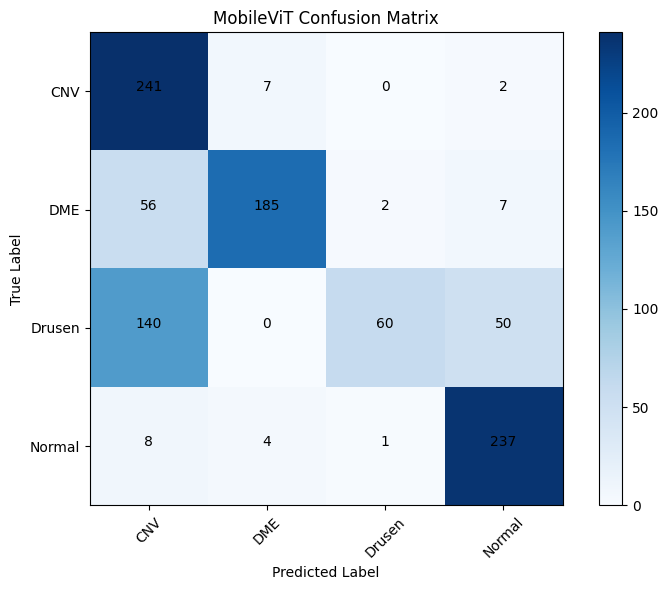

In [ ]:
cm_mobilevit = confusion_matrix(

    y_true_mobilevit,

    y_preds_mobilevit

)


plt.figure(figsize=(8,6))

plt.imshow(

    cm_mobilevit,

    interpolation='nearest',

    cmap='Blues'

)

plt.title("MobileViT Confusion Matrix")

plt.colorbar()


classes = [

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


tick_marks = np.arange(len(classes))


plt.xticks(

    tick_marks,

    classes,

    rotation=45

)


plt.yticks(

    tick_marks,

    classes

)


for i in range(cm_mobilevit.shape[0]):

    for j in range(cm_mobilevit.shape[1]):

        plt.text(

            j,

            i,

            format(cm_mobilevit[i, j], 'd'),

            ha="center",

            color="black"

        )


plt.ylabel('True Label')

plt.xlabel('Predicted Label')

plt.tight_layout()

plt.show()

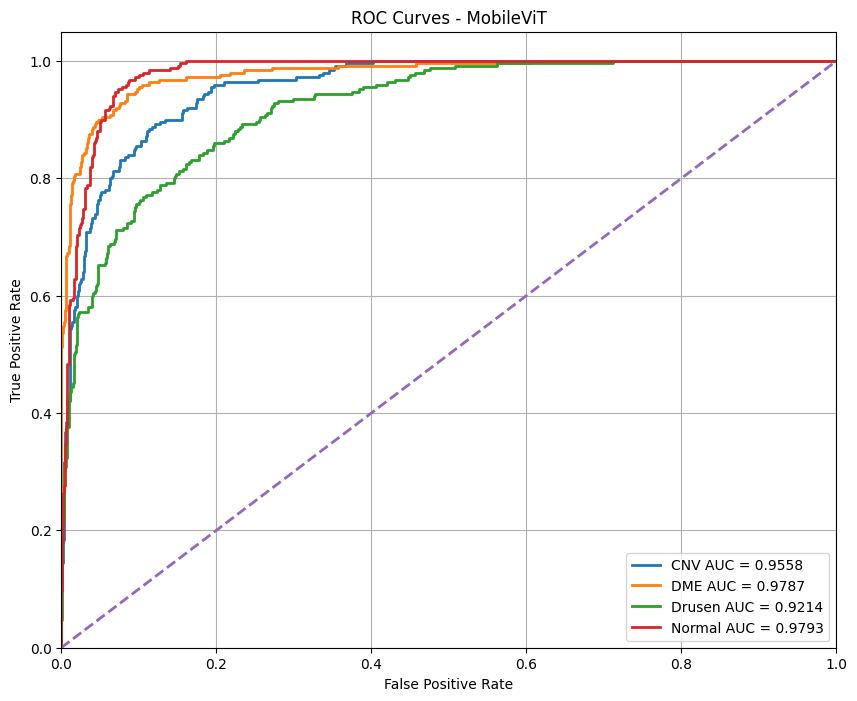

In [ ]:
from sklearn.metrics import (

    roc_curve,

    auc

)


y_true_bin_mobilevit = label_binarize(

    y_true_mobilevit,

    classes=[0,1,2,3]

)


class_names = [

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


fpr_mobilevit = {}

tpr_mobilevit = {}

roc_auc_mobilevit = {}


for i in range(4):

    fpr_mobilevit[i], tpr_mobilevit[i], _ = roc_curve(

        y_true_bin_mobilevit[:, i],

        np.array(y_probs_mobilevit)[:, i]

    )

    roc_auc_mobilevit[i] = auc(

        fpr_mobilevit[i],

        tpr_mobilevit[i]

    )


plt.figure(figsize=(10,8))


for i in range(4):

    plt.plot(

        fpr_mobilevit[i],

        tpr_mobilevit[i],

        lw=2,

        label=f"{class_names[i]} AUC = {roc_auc_mobilevit[i]:.4f}"

    )


plt.plot(

    [0,1],

    [0,1],

    linestyle='--',

    lw=2

)


plt.xlim([0.0,1.0])

plt.ylim([0.0,1.05])

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves - MobileViT")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

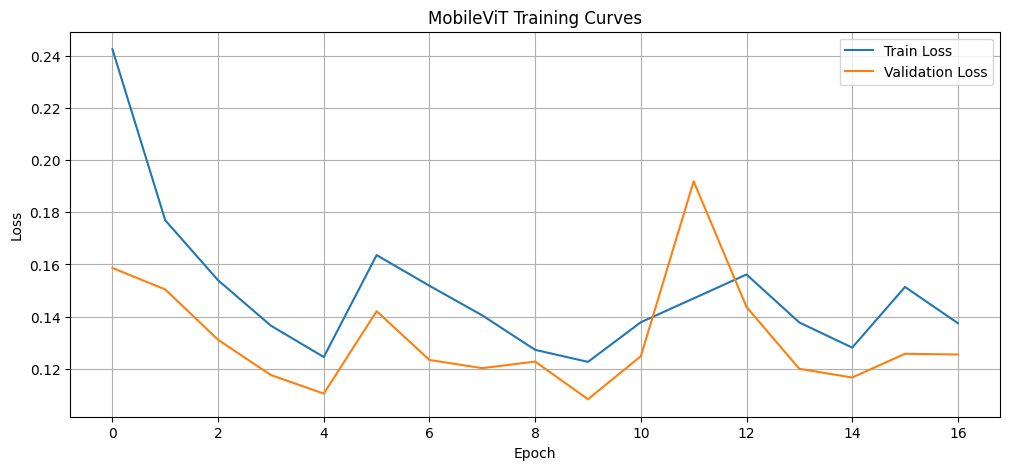

In [ ]:
plt.figure(figsize=(12,5))


plt.plot(

    history_mobilevit["train_loss"],

    label="Train Loss"

)


plt.plot(

    history_mobilevit["val_loss"],

    label="Validation Loss"

)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("MobileViT Training Curves")

plt.legend()

plt.grid(True)

plt.show()

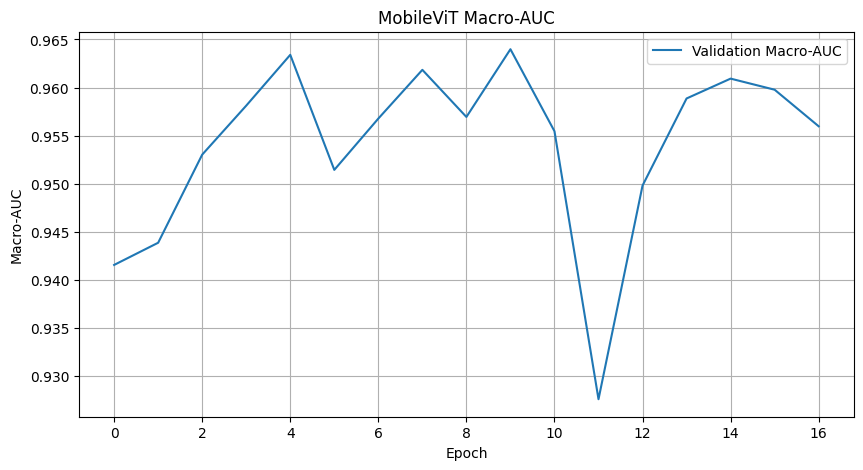

In [ ]:
plt.figure(figsize=(10,5))


plt.plot(

    history_mobilevit["val_auc"],

    label="Validation Macro-AUC"

)


plt.xlabel("Epoch")

plt.ylabel("Macro-AUC")

plt.title("MobileViT Macro-AUC")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
paper_table_mobilevit = pd.DataFrame({

    "Class": [

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ],

    "Precision": [

        report_mobilevit["CNV"]["precision"],

        report_mobilevit["DME"]["precision"],

        report_mobilevit["Drusen"]["precision"],

        report_mobilevit["Normal"]["precision"]

    ],

    "Recall": [

        report_mobilevit["CNV"]["recall"],

        report_mobilevit["DME"]["recall"],

        report_mobilevit["Drusen"]["recall"],

        report_mobilevit["Normal"]["recall"]

    ],

    "F1-Score": [

        report_mobilevit["CNV"]["f1-score"],

        report_mobilevit["DME"]["f1-score"],

        report_mobilevit["Drusen"]["f1-score"],

        report_mobilevit["Normal"]["f1-score"]

    ],

    "AUC": [

        roc_auc_mobilevit[0],

        roc_auc_mobilevit[1],

        roc_auc_mobilevit[2],

        roc_auc_mobilevit[3]

    ]

})


paper_table_mobilevit = paper_table_mobilevit.round(4)

print(paper_table_mobilevit)

    Class  Precision  Recall  F1-Score     AUC
0     CNV     0.5416   0.964    0.6935  0.9558
1     DME     0.9439   0.740    0.8296  0.9787
2  Drusen     0.9524   0.240    0.3834  0.9214
3  Normal     0.8007   0.948    0.8681  0.9793
